# Fig2

This notebook reads pre-aggregated metric tables and draws Fig2.

- Aggregation script: `main_figures/aggregate_fig2_metrics.py`
- Input files: `all_w1.csv`, `all_pseudotime.csv`, `all_tcvc.csv`
- Plot filter: `alignment == 'gpa'` and `dim == 10` (configurable).

In [50]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# Manuscript figure defaults
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings("ignore")
import os
from pathlib import Path

# Global matplotlib rcParams
plt.rcParams.update({
    "figure.dpi": 300,              # high resolution
    "savefig.dpi": 300,             # export resolution
    "savefig.format": "pdf",        # vector PDF
    "font.family": "sans-serif",    # sans-serif
    "font.sans-serif": [
        "Arial",        
],
    "pdf.fonttype": 42,             # embed TrueType (Adobe-editable)
    "ps.fonttype": 42,              # embed PostScript fonts
    "svg.fonttype": "none",         # keep SVG text as text
    "font.size": 8,                 # body size
    "axes.labelsize": 8,            # axis labels
    "axes.titlesize": 9,            # titles
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,          # spine width
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.direction": "out",       # ticks outward
    "ytick.direction": "out",
    "xtick.top": False,             # hide top ticks
    "ytick.right": False,           # hide right ticks
})

# Seaborn theme
sns.set_theme(
    style="ticks",                  # ticks style
    context="paper",                # paper context
    palette="colorblind"            # colorblind palette (Okabe-Ito)
)
print(plt.rcParams['font.family'])


# Color palette
COLOR_PALETTE = {
    'hvg': '#7F8C8D',           # muted gray (baseline)
    'genecompass': '#3498DB',   # blue
    'geneformer': '#E67E22',    # orange
    'scfoundation': '#9B59B6',  # purple
    'scgpt': '#E74C3C',         # red
    'uce': '#16A085',           # teal
    'scvi': '#2C3E50',          # dark blue-gray (HVG-scVI)
    'scvi_nobatch': '#5D6D7E',  # blue-gray (HVG-scVI, no batch)
}

DATASETS_TIME_DICT = {
    'EMT': 4,
    'HSPC': 4,
    'Mouse_hematopoiesis_onlylineage': 3,
    'Veres_subset': 8,
    'ebdata': 5,
}

DATASET_MARKERS = {
    'EMT': 'o',
    'HSPC': 'X',
    'Mouse_hematopoiesis_onlylineage': 's',
    'Veres_subset': 'p',
    'ebdata': 'v',
}

DATASET_DISPLAY_NAMES = {
    'EMT': 'EMT',
    'HSPC': 'HSPC',
    'Mouse_hematopoiesis_onlylineage': 'Mouse HSPC',
    'Veres_subset': 'Veres',
    'ebdata': 'EBdata',
}

POINT_MARKERS = {
    'true': 'o',
    'pred': 'x',
}

MODEL_LABEL_MAP = {
    "hvg": "HVG-PCA",
    "scvi": "HVG-scVI",
    "scvi_nobatch": "HVG-scVI\n(no batch)",
}


ALIGNMENT_TO_PLOT = 'gpa'
DIM_TO_PLOT = 10

os.makedirs('./fig2', exist_ok=True)


['sans-serif']


In [51]:
def _resolve_metric_dir() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [
        cwd,
        cwd / 'main_figures',
        cwd.parent / 'main_figures',
    ]
    for d in candidates:
        if (d / 'all_w1.csv').exists() and (d / 'all_pseudotime.csv').exists() and (d / 'all_tcvc.csv').exists():
            return d
    return cwd / 'main_figures'

# METRIC_DIR = _resolve_metric_dir()
METRIC_DIR = Path('./')

W1_PATH = METRIC_DIR / 'all_w1.csv'
PSEUDO_PATH = METRIC_DIR / 'all_pseudotime.csv'
TCVC_PATH = METRIC_DIR / 'all_tcvc.csv'

for p in [W1_PATH, PSEUDO_PATH, TCVC_PATH]:
    if not p.exists():
        raise FileNotFoundError(
            f'Missing {p}. Run: python main_figures/aggregate_fig2_metrics.py --output-dir main_figures'
        )

print(f'Using METRIC_DIR: {METRIC_DIR}')

def replace_dataset(df):
    df = df.copy()
    df['dataset'] = df['dataset'].astype(str).str.replace(r'_holdt\d+$', '', regex=True)
    return df

def task_assignment(df):
    df = df.copy()
    df['task'] = [None] * len(df)
    for dataset, alltime in DATASETS_TIME_DICT.items():
        mask = (df['dataset'] == dataset)
        if not mask.any():
            continue
        df.loc[mask & np.array([i in range(alltime)[1:-1] for i in df['time']]), 'task'] = 'Interpolation'
        df.loc[mask & (df['time'] == 0), 'task'] = 'Backtracking'
        df.loc[mask & (df['time'] == alltime - 1), 'task'] = 'Extrapolation'
    return df

def task_asignment(df):
    # Keep same helper name as original notebook for minimal diff in plotting cells.
    return task_assignment(df)

df_w1 = task_assignment(replace_dataset(pd.read_csv(W1_PATH)))
df_pseudo = task_assignment(replace_dataset(pd.read_csv(PSEUDO_PATH)))
df_tcvc = task_assignment(replace_dataset(pd.read_csv(TCVC_PATH)))

print('Loaded:')
print('W1      :', df_w1.shape)
print('Pseudo  :', df_pseudo.shape)
print('TCVC    :', df_tcvc.shape)
print('Models  :', sorted(df_w1['model'].unique().tolist()))
print('Datasets:', sorted(df_w1['dataset'].unique().tolist()))


Using METRIC_DIR: .
Loaded:
W1      : (11111, 12)
Pseudo  : (11111, 12)
TCVC    : (11111, 10)
Models  : ['genecompass', 'geneformer', 'hvg', 'scfoundation', 'scgpt', 'scvi', 'scvi_nobatch', 'uce']
Datasets: ['EMT', 'HSPC', 'Mouse_hematopoiesis_onlylineage', 'Veres_subset', 'ebdata']


Backtracking: 160 samples
Interpolation: 448 samples
Extrapolation: 160 samples


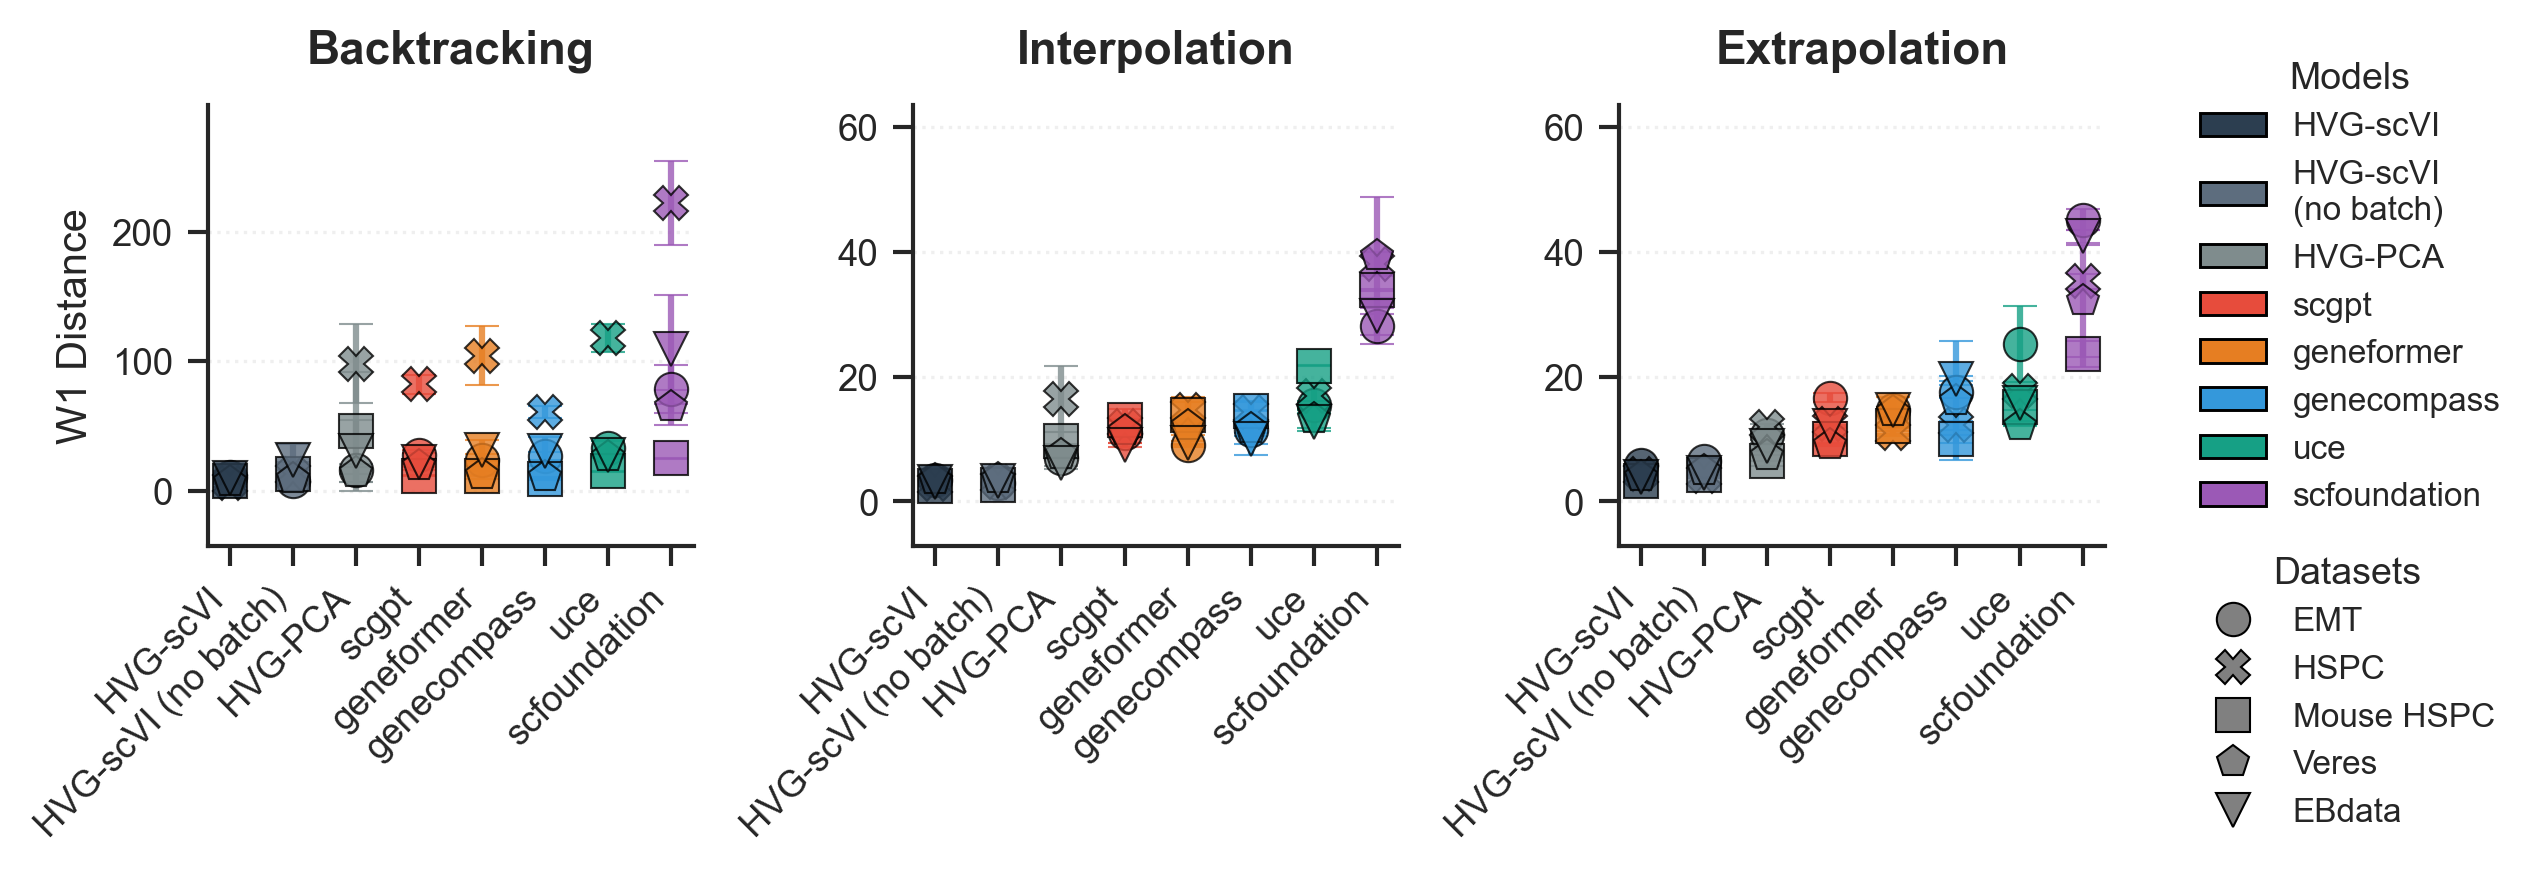

In [52]:
# Filter metric tables to the three holdout tasks
# dim=10, GPA alignment
# Keep all OT modes; plot mean ± std across them
# 1. Backtracking (time=0)
alignment = 'gpa'

df_back = df_w1[(df_w1['task'] == 'Backtracking') &
                (df_w1['dim'] == 10) &
                (df_w1['alignment'] == alignment)].copy()

# 2. Interpolation (intermediate time points)
df_inter = df_w1[(df_w1['task'] == 'Interpolation') &
                 (df_w1['dim'] == 10) &
                 (df_w1['alignment'] == alignment)].copy()

# 3. Extrapolation (last time point)
df_ext = df_w1[(df_w1['task'] == 'Extrapolation') &
               (df_w1['dim'] == 10) &
               (df_w1['alignment'] == alignment)].copy()

print(f"Backtracking: {df_back.shape[0]} samples")
print(f"Interpolation: {df_inter.shape[0]} samples")
print(f"Extrapolation: {df_ext.shape[0]} samples")

# y-limits: Backtracking separate; Interpolation and Extrapolation share a scale
all_data = pd.concat([df_back, df_inter, df_ext])
active_datasets = [d for d in DATASET_MARKERS.keys() if d in all_data['dataset'].unique()]

def _compute_task_ylim(df, margin_ratio=0.08):
    if df.empty:
        return (0.0, 1.0)
    grouped_std = df.groupby(['model', 'dataset'])['W1_Mean'].std().fillna(0.0)
    std_pad = float(grouped_std.max()) if len(grouped_std) > 0 else 0.0
    y0 = float(df['W1_Mean'].min())
    y1 = float(df['W1_Mean'].max())
    span = max(y1 - y0, 1e-8)
    pad = max(std_pad, span * margin_ratio)
    return y0 - pad, y1 + pad

back_ymin, back_ymax = _compute_task_ylim(df_back)
future_df = pd.concat([df_inter, df_ext], ignore_index=True)
future_ymin, future_ymax = _compute_task_ylim(future_df)

# 1x3 panels with independent y-axes
fig, axes = plt.subplots(1, 3, figsize=(7.2, 3), sharey=False)

# order models by Interpolation mean W1
all_models = df_inter.groupby('model')['W1_Mean'].mean().sort_values().index.tolist()

# one panel per task
for idx, (ax, df_task, task_name) in enumerate(zip(
    axes,
    [df_back, df_inter, df_ext],
    ['Backtracking', 'Interpolation', 'Extrapolation']
)):

    # mean ± std per model and dataset
    for i, model in enumerate(all_models):
        model_data = df_task[df_task['model'] == model]

        for dataset in active_datasets:
            dataset_data = model_data[model_data['dataset'] == dataset]

            if len(dataset_data) > 0:
                # mean and std
                mean_val = dataset_data['W1_Mean'].mean()
                std_val = dataset_data['W1_Mean'].std()

                # error bars
                ax.errorbar(i, mean_val, yerr=std_val,
                           marker=DATASET_MARKERS[dataset],
                           markersize=8,
                           color=COLOR_PALETTE.get(model, '#888888'),
                           markeredgecolor='black',
                           markeredgewidth=0.5,
                           ecolor=COLOR_PALETTE.get(model, '#888888'),
                           elinewidth=1.5,
                           capsize=4,
                           capthick=1.5,
                           alpha=0.8,
                           linestyle='none')

    # Backtracking has its own y-limits; the other two tasks share one
    if task_name == 'Backtracking':
        ax.set_ylim(back_ymin, back_ymax)
    else:
        ax.set_ylim(future_ymin, future_ymax)

    # axes
    ax.set_xticks(range(len(all_models)))
    model_labels = ["HVG-scVI (no batch)" if m == "scvi_nobatch" else MODEL_LABEL_MAP.get(m, m)
                        for m in all_models]
    ax.set_xticklabels(model_labels,
                       rotation=45, ha='right')
    ax.set_ylabel('W1 Distance' if idx == 0 else '', fontsize=10)
    ax.set_title(task_name, fontsize=11, weight='bold', pad=10)
    ax.grid(axis='y', alpha=0.3, linestyle=':')

# legends
# model color legend
model_legend = [plt.Line2D([0], [0], marker='_', color='w',
                           markerfacecolor=COLOR_PALETTE.get(m, '#888888'),
                           markersize=8, label=MODEL_LABEL_MAP.get(m, m),
                           markeredgecolor='black', markeredgewidth=0.5)
                for m in all_models]
# Model legend: colored rectangles
import matplotlib.patches as mpatches
model_legend = [
    mpatches.Rectangle((0,0), 1, 1,
        facecolor=COLOR_PALETTE.get(m, '#888888'),
        edgecolor='black',
        linewidth=0.7,
        label=MODEL_LABEL_MAP.get(m, m)
    )
    for m in all_models
]

# dataset marker legend
labels = {ds: DATASET_DISPLAY_NAMES.get(ds, ds.replace('_', ' ')) for ds in active_datasets}

dataset_legend = [plt.Line2D([0], [0], marker=DATASET_MARKERS[ds], color='w',
                             markerfacecolor='gray', markersize=8,
                             label=labels[ds],
                             markeredgecolor='black', markeredgewidth=0.5)
                  for ds in active_datasets]

# legends on the right
fig.legend(handles=model_legend, loc='upper left', bbox_to_anchor=(1.01, 0.95),
          fontsize=8, title='Models', title_fontsize=9, frameon=False)
fig.legend(handles=dataset_legend, loc='upper left', bbox_to_anchor=(1.01, 0.40),
          fontsize=8, title='Datasets', title_fontsize=9, frameon=False)

sns.despine()
plt.tight_layout()
plt.savefig('./fig2/w1_errorbar_three_tasks.pdf', dpi=300, bbox_inches='tight')
plt.show()


Datasets in current plotting run: ['EMT', 'Mouse_hematopoiesis_onlylineage', 'Veres_subset']
Backtracking: 160 samples
Interpolation: 448 samples
Extrapolation: 160 samples

Shared x-axis range: [0, 1]


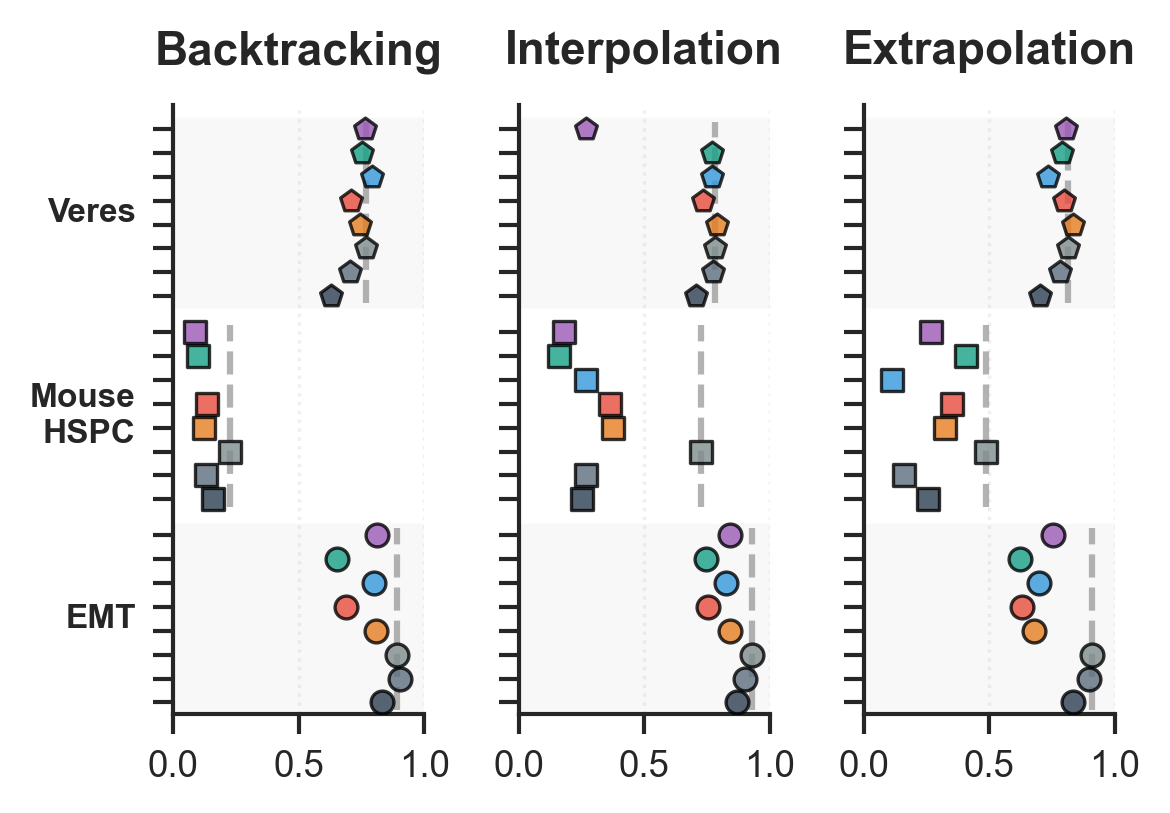


Per-task model-dataset scores:

Backtracking:

EMT:
  scvi           : 0.833 ± 0.002
  scvi_nobatch   : 0.901 ± 0.002
  hvg            : 0.890 ± 0.002
  geneformer     : 0.806 ± 0.000
  scgpt          : 0.686 ± 0.008
  genecompass    : 0.798 ± 0.013
  uce            : 0.651 ± 0.002
  scfoundation   : 0.812 ± 0.002

Mouse_hematopoiesis_onlylineage:
  scvi           : 0.159 ± 0.041
  scvi_nobatch   : 0.129 ± 0.007
  hvg            : 0.226 ± 0.093
  geneformer     : 0.123 ± 0.036
  scgpt          : 0.134 ± 0.074
  genecompass    : -0.054 ± 0.021
  uce            : 0.096 ± 0.070
  scfoundation   : 0.084 ± 0.029

Veres_subset:
  scvi           : 0.626 ± 0.011
  scvi_nobatch   : 0.704 ± 0.007
  hvg            : 0.766 ± 0.024
  geneformer     : 0.743 ± 0.064
  scgpt          : 0.707 ± 0.095
  genecompass    : 0.790 ± 0.004
  uce            : 0.751 ± 0.034
  scfoundation   : 0.762 ± 0.063

Interpolation:

EMT:
  scvi           : 0.869 ± 0.004
  scvi_nobatch   : 0.903 ± 0.005
  hvg            

In [53]:
# Pseudotime is a secondary metric; show a subset of datasets
selected_datasets = ['EMT','Veres_subset', 'Mouse_hematopoiesis_onlylineage']

# Filter pseudotime tables to the three holdout tasks
# dim=10, GPA alignment

metric = 'Spearman_Mean'

if metric == 'TC':
    df_pseudo = df_tcvc.copy()
else:
    df_pseudo = df_pseudo.copy()

df_pseudo = replace_dataset(df_pseudo)
df_pseudo = task_asignment(df_pseudo)
all_datasets = [d for d in DATASETS_TIME_DICT.keys() if d in selected_datasets]
print('Datasets in current plotting run:', all_datasets)
df_pseudo.head()

alignment = 'gpa'
# 1. Backtracking (time=0)
df_pseudo_back = df_pseudo[(df_pseudo['task'] == 'Backtracking') &
                           (df_pseudo['dim'] == 10) &
                        #    (df_pseudo['otmode'] == 'dot') &
                           (df_pseudo['alignment'] == alignment)].copy()

# 2. Interpolation (intermediate time points)
df_pseudo_inter = df_pseudo[(df_pseudo['task'] == 'Interpolation') &
                            (df_pseudo['dim'] == 10) &
                        #    (df_pseudo['otmode'] == 'dot') &
                            (df_pseudo['alignment'] == alignment)].copy()

# 3. Extrapolation (last time point)
df_pseudo_ext = df_pseudo[(df_pseudo['task'] == 'Extrapolation') &
                          (df_pseudo['dim'] == 10) &
                        #    (df_pseudo['otmode'] == 'dot') &
                          (df_pseudo['alignment'] == alignment)].copy()

print(f"Backtracking: {df_pseudo_back.shape[0]} samples")
print(f"Interpolation: {df_pseudo_inter.shape[0]} samples")
print(f"Extrapolation: {df_pseudo_ext.shape[0]} samples")

# shared x-limits
x_min_pseudo = 0  # Spearman lower bound
x_max_pseudo = 1  # Spearman upper bound

print(f"\nShared x-axis range: [{x_min_pseudo}, {x_max_pseudo}]")

# 1x3 panels
fig, axes = plt.subplots(1, 3, figsize=(4, 2.8), sharey=True)

# preferred model order (same narrative as the W1 panel)
preferred_models = ['scvi', 'scvi_nobatch', 'hvg', 'geneformer', 'scgpt', 'genecompass', 'uce', 'scfoundation', ]
all_models = [m for m in preferred_models if m in df_pseudo['model'].unique()]

# y-axis: datasets grouped, models within each group
y_labels = []
y_positions = []
y_pos = 0

dataset_positions = {}  # y-range per dataset for bands and baselines

for dataset in all_datasets:
    dataset_start = y_pos
    for model in all_models:
        y_labels.append(f"{model}")
        y_positions.append(y_pos)
        y_pos += 1
    dataset_end = y_pos - 1
    dataset_positions[dataset] = (dataset_start, dataset_end)
    y_pos += 0.5  # gap between datasets

# one panel per task
for idx, (ax, df_task, task_name) in enumerate(zip(
    axes,
    [df_pseudo_back, df_pseudo_inter, df_pseudo_ext],
    ['Backtracking', 'Interpolation', 'Extrapolation']
)):
    
    # light background bands per dataset
    for i, dataset in enumerate(all_datasets):
        start_pos, end_pos = dataset_positions[dataset]
        if i % 2 == 0:  # alternating row shading
            ax.axhspan(start_pos - 0.5, end_pos + 0.5, 
                      facecolor='lightgray', alpha=0.15, zorder=0)
    
    # scatter and baseline
    y_pos = 0
    for dataset in all_datasets:
        hvg_value = None  # HVG value for the baseline
        
        for model in all_models:
            # subset to this model-dataset pair
            model_dataset_data = df_task[(df_task['model'] == model) & 
                                         (df_task['dataset'] == dataset)]
            
            if len(model_dataset_data) > 0:
                # mean across OT modes (unused; points are plotted per OT mode)
                mean_val = model_dataset_data[metric].mean()
                # scatter
                # plot each OT mode as a point instead of averaging
                y_pos_all = [y_pos] * len(model_dataset_data)
                ax.scatter(mean_val, y_pos,
                          marker=DATASET_MARKERS[dataset],
                          s=30,
                          color=COLOR_PALETTE.get(model, '#888888'),
                          alpha=0.8,
                          edgecolors='black',
                          linewidths=0.8,
                          zorder=3)
                
                # store HVG value
                if model == 'hvg':
                    mean_val = model_dataset_data[metric].mean()
                    hvg_value = mean_val
            
            y_pos += 1
        
        # HVG baseline (vertical line)
        if hvg_value is not None:
            start_pos, end_pos = dataset_positions[dataset]
            ax.vlines(hvg_value, start_pos - 0.3, end_pos + 0.3,
                     colors='gray', linestyles='--', linewidth=1.5,
                     alpha=0.6, zorder=1)
        
        y_pos += 0.5  # gap between datasets
    
    # shared x-limits
    ax.set_xlim(x_min_pseudo, x_max_pseudo)
    
    # axes
    ax.set_ylim(-0.5, y_pos - 0.5)
    ax.set_yticks(y_positions)
    
    # y-tick labels on the first panel only
    if idx == 0:
        # y-tick labels: model names within each dataset group
        y_tick_labels = []
        for dataset in all_datasets:
            for model in all_models:
                y_tick_labels.append(MODEL_LABEL_MAP.get(model, model))
        ax.set_yticklabels(y_tick_labels, fontsize=6.5)
        
        # dataset group labels on the left
        for dataset in all_datasets:
            start_pos, end_pos = dataset_positions[dataset]
            mid_pos = (start_pos + end_pos) / 2
            display_name = DATASET_DISPLAY_NAMES.get(dataset, dataset).replace(' ', '\n', 1) if dataset == 'Mouse_hematopoiesis_onlylineage' else DATASET_DISPLAY_NAMES.get(dataset, dataset)
            ax.text(-0.15, mid_pos, display_name, 
                   ha='right', va='center', fontsize=8,
                   weight='bold', transform=ax.get_yaxis_transform())
    else:
        ax.set_yticklabels([])
    
    # ax.set_xlabel('Spearman Correlation', fontsize=10)
    ax.set_title(task_name, fontsize=11, weight='bold', pad=10)
    ax.grid(axis='x', alpha=0.3, linestyle=':')

sns.despine()
plt.tight_layout()
if metric == 'TC':
    plt.savefig('./fig2/tc_scatter_grouped_three_tasks.pdf', dpi=300, bbox_inches='tight')
else:
    plt.savefig('./fig2/pseudotime_scatter_grouped_three_tasks.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("\nPer-task model-dataset scores:")
for task_name, df_task in [('Backtracking', df_pseudo_back), 
                           ('Interpolation', df_pseudo_inter), 
                           ('Extrapolation', df_pseudo_ext)]:
    print(f"\n{'='*70}")
    print(f"{task_name}:")
    print(f"{'='*70}")
    
    for dataset in all_datasets:
        print(f"\n{dataset}:")
        for model in all_models:
            model_dataset_data = df_task[(df_task['model'] == model) & 
                                         (df_task['dataset'] == dataset)]
            if len(model_dataset_data) > 0:
                mean_val = model_dataset_data[metric].mean()
                std_val = model_dataset_data[metric].std()
                print(f"  {model:15s}: {mean_val:.3f} ± {std_val:.3f}")


Interpolation raw points: 448 samples
Interpolation aggregated points: 160 samples (mean over time)
Backtracking: 160 samples
Interpolation (aggregated): 160 samples
Extrapolation: 160 samples


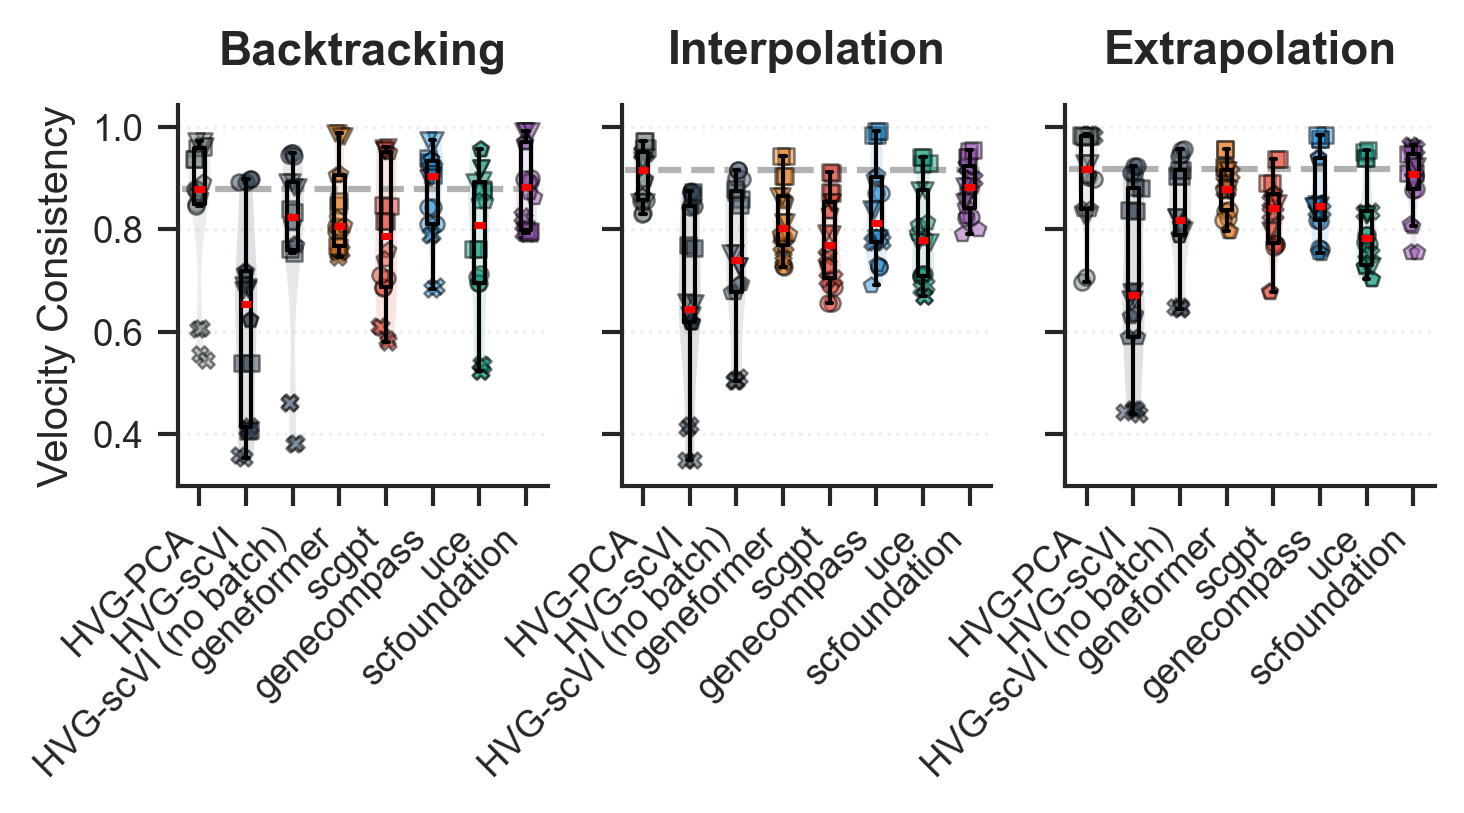


Per-task VC summary:

Backtracking:
  hvg            : mean=0.847, median=0.879, std=0.144, IQR=[0.848, 0.959], range=[0.545, 0.972]
  scvi           : mean=0.622, median=0.653, std=0.188, IQR=[0.415, 0.719], range=[0.353, 0.899]
  scvi_nobatch   : mean=0.769, median=0.824, std=0.190, IQR=[0.759, 0.892], range=[0.381, 0.950]
  geneformer     : mean=0.842, median=0.807, std=0.086, IQR=[0.767, 0.906], range=[0.747, 0.988]
  scgpt          : mean=0.787, median=0.787, std=0.137, IQR=[0.687, 0.951], range=[0.580, 0.960]
  genecompass    : mean=0.872, median=0.904, std=0.086, IQR=[0.810, 0.933], range=[0.684, 0.975]
  uce            : mean=0.773, median=0.808, std=0.151, IQR=[0.696, 0.893], range=[0.523, 0.957]
  scfoundation   : mean=0.882, median=0.882, std=0.078, IQR=[0.799, 0.971], range=[0.792, 0.992]

Interpolation:
  hvg            : mean=0.906, median=0.916, std=0.051, IQR=[0.856, 0.950], range=[0.830, 0.972]
  scvi           : mean=0.665, median=0.645, std=0.176, IQR=[0.619, 0.845]

In [55]:
# Velocity consistency (VC): violins + boxes + scatter
# Three panels: Backtracking, Interpolation, Extrapolation
# violins + boxes + scatter (marker shape encodes dataset)

df_vc = df_tcvc.copy()

# Prepare data
alignment = 'gpa'
model_gap = 1.3  # Increase spacing between model groups without changing figure width.
df_vc_back = df_vc[(df_vc['task'] == 'Backtracking') &
                   (df_vc['dim'] == 10) &
                   (df_vc['alignment'] == alignment)].copy()

df_vc_inter_raw = df_vc[(df_vc['task'] == 'Interpolation') &
                        (df_vc['dim'] == 10) &
                        (df_vc['alignment'] == alignment)].copy()

# Interpolation: average VC across time points within model, dataset, OT mode
df_vc_inter = df_vc_inter_raw.groupby(['model', 'dataset', 'otmode']).agg({
    'VC': 'mean',
    'dim': 'first',
    'alignment': 'first',
    'task': 'first'
}).reset_index()

print(f"Interpolation raw points: {df_vc_inter_raw.shape[0]} samples")
print(f"Interpolation aggregated points: {df_vc_inter.shape[0]} samples (mean over time)")

df_vc_ext = df_vc[(df_vc['task'] == 'Extrapolation') &
                  (df_vc['dim'] == 10) &
                  (df_vc['alignment'] == alignment)].copy()

print(f"Backtracking: {df_vc_back.shape[0]} samples")
print(f"Interpolation (aggregated): {df_vc_inter.shape[0]} samples")
print(f"Extrapolation: {df_vc_ext.shape[0]} samples")

# shared y-limits
all_vc_data = pd.concat([df_vc_back, df_vc_inter, df_vc_ext])
y_min = all_vc_data['VC'].min() - 0.05
y_max = all_vc_data['VC'].max() + 0.05

# 1x3 panels
fig, axes = plt.subplots(1, 3, figsize=(5, 2.8), sharey=True)

# preferred model order (same narrative as the W1 panel)
preferred_models = ['hvg', 'scvi', 'scvi_nobatch', 'geneformer', 'scgpt', 'genecompass', 'uce', 'scfoundation']
all_models = [m for m in preferred_models if m in all_vc_data['model'].unique()]
all_datasets = sorted([d for d in DATASET_MARKERS.keys() if d in all_vc_data['dataset'].unique()])

# one panel per task
for idx, (ax, df_task, task_name) in enumerate(zip(
    axes,
    [df_vc_back, df_vc_inter, df_vc_ext],
    ['Backtracking', 'Interpolation', 'Extrapolation']
)):
    
    # violin data: all points per model (across datasets and OT modes)
    violin_data = []
    violin_positions = []
    violin_colors = []
    
    for i, model in enumerate(all_models):
        model_data = df_task[df_task['model'] == model]['VC'].values
        if len(model_data) > 0:
            violin_data.append(model_data)
            violin_positions.append(i * model_gap)
            violin_colors.append(COLOR_PALETTE.get(model, '#888888'))
    
    # violins
    parts = ax.violinplot(violin_data, positions=violin_positions, 
                          widths=0.62, showmeans=False, showmedians=False, showextrema=False)
    
    # violin colors
    for pc, color in zip(parts['bodies'], violin_colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.15)
        pc.set_edgecolor('none')

    
    # boxplots on top of violins
    bp = ax.boxplot(violin_data, positions=violin_positions,
                    widths=0.3,  # narrower boxes
                    patch_artist=False,
                    showfliers=False,  # hide outliers
                    medianprops=dict(color='red', linewidth=1.7, solid_capstyle='butt'),
                    boxprops=dict(color='black', linewidth=1),
                    whiskerprops=dict(color='black', linewidth=1.0),
                    capprops=dict(color='black', linewidth=1.0),
                    zorder=5)
    
    # overlay scatter, shaped by dataset
    hvg_value = None
    for i, model in enumerate(all_models):
        model_data = df_task[df_task['model'] == model]
        
        # HVG median/mean for the baseline
        if model == 'hvg':
            hvg_value = model_data['VC'].median()
        
        for dataset in all_datasets:
            dataset_data = model_data[model_data['dataset'] == dataset]
            
            if len(dataset_data) > 0:
                # jitter points within a model-dataset group to reduce overlap
                x_positions = np.random.normal(i * model_gap, 0.08, size=len(dataset_data))
                
                # scatter
                ax.scatter(x_positions, dataset_data['VC'].values,
                          marker=DATASET_MARKERS[dataset],
                          s=15,
                          color=COLOR_PALETTE.get(model, '#888888'),
                          alpha=0.5,
                          edgecolors='black',
                          linewidths=0.6,
                          zorder=3)
    
    # HVG baseline (horizontal dashed line)
    if hvg_value is not None:
        start_pos = -0.5
        end_pos = (len(all_models) - 1) * model_gap + 0.5
        ax.hlines(hvg_value, start_pos, end_pos, 
                 colors='gray', linestyles='--', linewidth=1.5,
                 alpha=0.6, zorder=1)
    
    # shared y-limits
    ax.set_ylim(y_min, y_max)
    
    # axes
    ax.set_xticks([i * model_gap for i in range(len(all_models))])
    ax.set_xlim(-0.6, (len(all_models) - 1) * model_gap + 0.6)
    model_labels = ["HVG-scVI (no batch)" if m == "scvi_nobatch" else MODEL_LABEL_MAP.get(m, m)
                        for m in all_models]
    ax.set_xticklabels(model_labels,
                       rotation=45, ha='right')
    ax.set_ylabel('Velocity Consistency' if idx == 0 else '', fontsize=10)
    ax.set_title(task_name, fontsize=11, weight='bold', pad=10)
    ax.grid(axis='y', alpha=0.3, linestyle=':')


sns.despine()
plt.tight_layout()
plt.subplots_adjust(wspace=0.2)
plt.savefig('./fig2/vc_violin_three_tasks.pdf', dpi=300, bbox_inches='tight')
plt.show()

# print summary stats
print("\nPer-task VC summary:")
print("=" * 70)

for task_name, df_task in [('Backtracking', df_vc_back), 
                           ('Interpolation', df_vc_inter), 
                           ('Extrapolation', df_vc_ext)]:
    print(f"\n{task_name}:")
    for model in all_models:
        model_data = df_task[df_task['model'] == model]
        if len(model_data) > 0:
            mean_val = model_data['VC'].mean()
            std_val = model_data['VC'].std()
            median_val = model_data['VC'].median()
            min_val = model_data['VC'].min()
            max_val = model_data['VC'].max()
            q25 = model_data['VC'].quantile(0.25)
            q75 = model_data['VC'].quantile(0.75)
            print(f"  {model:15s}: mean={mean_val:.3f}, median={median_val:.3f}, std={std_val:.3f}, "
                  f"IQR=[{q25:.3f}, {q75:.3f}], range=[{min_val:.3f}, {max_val:.3f}]")
